# GENERATION EVENTS

**Description**: Generation change in the Smart Grid Management system will represent a situation where there will be a mutation in the properties of a plant such as capacity_mw

**We shall use an ID registry, to enforce unique ID's to node and edges**

In [1]:
class IDRegistry:
    """Class to register IDs for various entities"""
    def __init__(self):
        self.used_ids = set()

    def register(self, id: str):
        if id in self.used_ids:
            raise ValueError(f"Duplicate ID detected: {id}")
        self.used_ids.add(id)
        return id

    def unregister(self, id: str):
        """Remove an ID from the registry"""
        self.used_ids.discard(id)  # discard won't raise an error if id is missing

    def __repr__(self):
        return f"IDRegistry(used_ids={list(self.used_ids)})"

## Creating Node Class

#### 🧩 Node — Grid Entity

#### Description

A `Node` represents a **physical component** of the electrical grid.  
Each node belongs to **exactly one grid** and has a **unique identity**.

Nodes are **structural entities**. They do not store time-dependent behavior or simulation results.

---

#### Supported Node Types

| Type | Description |
|-----|------------|
| `PLANT` | Power generation source (hydro, solar, thermal) |
| `SUBSTATION` | Transmission or distribution junction |
| `LOAD` | Electricity consumer |

---

#### Attributes

| Attribute | Type | Required | Description |
|---------|------|----------|------------|
| `id` | `str` | ✅ | Unique node identifier |
| `type` | `GridNodeType` | ✅ | Node category |
| `plant_type` | `str` | PLANT only | Energy source (hydro, solar, thermal) |
| `load_type` | `str` | LOAD only | Consumer category |
| `demand_mw` | `float` | LOAD only | Power demand in megawatts |
| `capacity_mw` | `float` | PLANT / SUBSTATION | Maximum generatable or transferable power |
| `priority` | `int` | Optional | Priority used during load shedding |

---

#### Validation Rules

- A `PLANT` must define `plant_type` and `capacity_mw`
- A `LOAD` must define `load_type` and `demand_mw`
- A `SUBSTATION` must define `capacity_mw`
- Invalid attribute combinations are rejected

---

#### Behavioral Notes

- Nodes do not store power flow
- Nodes do not store time
- Nodes do not know about events
- Nodes are immutable within a snapshot


In [2]:
from enum import Enum

class GridNodeType(str, Enum):
    PLANT = "PLANT"
    LOAD = "LOAD"
    SUBSTATION = "SUBSTATION"

class PlantType(str, Enum):
    HYDRO = "hydro"
    SOLAR = "solar"
    THERMAL = "thermal"


class LoadType(str, Enum):
    HOSPITAL = "hospital"
    ENTERPRISE = "enterprise"
    RESIDENTIAL = "residential"
    INDUSTRIAL = "industrial"


def validate_node_attributes(node_data: dict):
    """Function that is used to validate the node attributes"""
    node_type = node_data.get("type")

    if node_type == GridNodeType.PLANT:
        if not node_data.get("plant_type"):
            raise ValueError("Plant node must have 'plant_type' set.")

        if node_data.get("load_type") is not None or node_data.get("demand_mw") is not None:
            raise ValueError("Plant node cannot have load attributes.")

        if node_data.get("capacity_mw") is None:
            raise ValueError("Plant node must have 'capacity_mw' set.")

        if node_data.get("priority") is None:
            node_data["priority"] = 0

    elif node_type == GridNodeType.LOAD:
        if not node_data.get("load_type"):
            raise ValueError("Load node must have 'load_type' set.")

        if node_data.get("demand_mw") is None:
            raise ValueError("Load node must have 'demand_mw' set.")

        if node_data.get("plant_type") is not None or node_data.get("capacity_mw") is not None:
            raise ValueError("Load node cannot have plant or capacity attributes.")

        if node_data.get("priority") is None:
            node_data["priority"] = 0

    elif node_type == GridNodeType.SUBSTATION:
        if node_data.get("plant_type") is not None or node_data.get("load_type") is not None:
            raise ValueError("Substation node cannot have plant or load attributes.")

        if node_data.get("demand_mw") is not None:
            raise ValueError("Substation node cannot have demand_mw.")

        if node_data.get("capacity_mw") is None:
            raise ValueError("Substation node must have 'capacity_mw' set.")

    else:
        raise ValueError(f"Unknown node type: {node_type}")


In [3]:
class Node:
    def __init__(
        self,
        id: str,
        type: GridNodeType,
        plant_type: PlantType = None,
        load_type: LoadType = None,
        demand_mw=None,
        capacity_mw=None,
        priority=0,
    ):
        node_data = {
            "type": type,
            "plant_type": plant_type,
            "load_type": load_type,
            "demand_mw": demand_mw,
            "capacity_mw": capacity_mw,
            "priority": priority,
        }
        
        # convert string to Enum if needed
        if isinstance(node_data["type"], str):
            node_data["type"] = GridNodeType(node_data["type"])
        if node_data.get("plant_type") and isinstance(node_data["plant_type"], str):
            node_data["plant_type"] = PlantType(node_data["plant_type"])
        if node_data.get("load_type") and isinstance(node_data["load_type"], str):
            node_data["load_type"] = LoadType(node_data["load_type"])

        validate_node_attributes(node_data)

        self.id = id_registry.register(id)
        self.type = node_data["type"]
        self.plant_type = node_data["plant_type"]
        self.load_type = node_data["load_type"]
        self.demand_mw = node_data["demand_mw"]
        self.capacity_mw = node_data["capacity_mw"]
        self.priority = node_data["priority"]

    def __repr__(self):
        return (
            f"Node(id={self.id}, type={self.type}, plant_type={self.plant_type}, "
            f"load_type={self.load_type}, demand_mw={self.demand_mw}, "
            f"capacity_mw={self.capacity_mw}, priority={self.priority})"
        )

#### 🔌 Edge — Transmission Line

#### Description

An `Edge` represents a **directed electrical transmission line** between two nodes.

Edges define **grid topology** and constrain how electricity flows through the grid.

---

#### Directionality

Edges are **directed**:


from_node ─────▶ to_node


Electricity may only flow in the declared direction.

---

#### Attributes

| Attribute | Type | Required | Description |
|---------|------|----------|------------|
| `id` | `str` | ✅ | Unique edge identifier |
| `from_node` | `Node.id` | ✅ | Source node |
| `to_node` | `Node.id` | ✅ | Target node |
| `capacity_mw` | `float` | ✅ | Maximum transferable power |
| `resistance` | `float` | Optional | Electrical resistance |
| `losses_percent` | `float` | Optional | Energy loss percentage (0–100) |
| `priority` | `int` | Optional | Used during overload resolution |
| `status` | `GridEdgeStatus` | Optional | `ACTIVE` or `OUTAGE` |

---

#### Validation Rules

- Self-loop edges are forbidden
- Parallel edges are forbidden
- Direction must respect node types:
  - `PLANT → SUBSTATION / LOAD`
  - `SUBSTATION → SUBSTATION / LOAD`
  - `LOAD → ❌`

---

#### Behavioral Notes

- Edge status may change during simulation
- Edges do not store power flow
- Power flow is always derived during simulation


In [4]:
from enum import Enum


class GridEdgeStatus(str, Enum):
    ACTIVE = "ACTIVE"
    DISABLED = "DISABLED"
    FAILED = "FAILED"


ALLOWED_FLOW = {
    "PLANT": {"SUBSTATION", "LOAD"},
    "SUBSTATION": {"SUBSTATION", "LOAD"},
    "LOAD": set(),
}


def validate_edge_attributes(edge_data: dict, from_node, to_node):
    # Self-loop
    if from_node.id == to_node.id:
        raise ValueError("Self-loop edges are not allowed")

    # Direction validation
    allowed_targets = ALLOWED_FLOW.get(from_node.type.value)
    if allowed_targets is None:
        raise ValueError(f"Unsupported from_node type: {from_node.type}")

    if to_node.type.value not in allowed_targets:
        raise ValueError(
            f"Invalid power flow: {from_node.type.value} → {to_node.type.value}"
        )

    # Capacity
    if edge_data.get("capacity_mw") is None or edge_data["capacity_mw"] <= 0:
        raise ValueError("Edge must have positive capacity_mw")

    # Losses
    losses = edge_data.get("losses_percent")
    if losses is not None and not (0 <= losses <= 100):
        raise ValueError("losses_percent must be between 0 and 100")


In [5]:
class Edge:
    def __init__(
        self,
        id: str,
        from_node: Node,
        to_node: Node,
        capacity_mw: float,
        resistance: float = None,
        losses_percent: float = None,
        priority: int = 0,
        status: GridEdgeStatus = GridEdgeStatus.ACTIVE,
    ):
        edge_data = {
            "capacity_mw": capacity_mw,
            "losses_percent": losses_percent,
        }

        if status and isinstance(status, str):
            status = GridEdgeStatus(status)
            
        validate_edge_attributes(edge_data, from_node, to_node)

        self.id = id_registry.register(id)
        self.from_node = from_node.id
        self.to_node = to_node.id
        self.capacity_mw = capacity_mw
        self.resistance = resistance
        self.losses_percent = losses_percent
        self.priority = priority
        self.status = status

    def __repr__(self):
            return (
                f"Edge(id={self.id}, from_node={self.from_node}, to_node={self.to_node}, "
                f"capacity_mw={self.capacity_mw}, resistance={self.resistance}, "
                f"losses_percent={self.losses_percent}, priority={self.priority}, "
                f"status={self.status})"
            )

## Directed Acyclic Graph (DAG)

### Purpose

The **Directed Acyclic Graph (DAG)** represents the electrical grid topology at a given snapshot in time.  
It models **nodes** (plants, substations, loads) and **directed edges** (power flow connections) while enforcing a **no-cycle constraint** at the logical level.

The DAG is the core structure used for:
- Grid traversal
- Island detection
- Power flow propagation
- Event-driven simulation

---

### Core Characteristics

- **Directed**  
  All edges have a defined direction (`from_node → to_node`) representing power flow.

- **Acyclic by Design**  
  The graph is expected to remain cycle-free.  
  Cycle prevention and validation are handled by an external **edge validator**, not the DAG itself.

- **Topology-Only Responsibility**  
  The DAG stores and manages:
  - Node existence
  - Edge connectivity
  - Adjacency relationships  
  It does **not** perform domain validation or business rules.

---

### Data Representation

The DAG is implemented using **adjacency lists** with explicit edge objects.

- **Nodes**
  - Stored as a mapping: `node_id → Node`
  - Nodes are treated as immutable structural entities

- **Edges**
  - Stored as a mapping: `edge_id → Edge`
  - Edges are first-class objects with metadata (capacity, status, etc.)

- **Adjacency Lists**
  - `adj`: Outgoing edges (`node_id → [Edge]`)
  - `rev_adj`: Incoming edges (`node_id → [Edge]`)

This dual adjacency structure allows:
- Efficient forward traversal
- Efficient backward traversal
- Fast island detection

---

### Identity Management

- Node and Edge IDs are managed externally by an **IDRegistry**
- The DAG does not generate IDs
- On removal of nodes or edges, the DAG ensures:
  - Structural cleanup
  - ID deregistration via the shared registry

This separation prevents tight coupling and ensures global ID consistency.

---

### Supported Operations

- Add / remove nodes
- Add / remove edges
- Query outgoing and incoming edges
- Neighbor discovery
- Edge existence checks
- Island (connected component) detection
- Full node and edge iteration

---

### Design Principles

- **Single Responsibility**  
  The DAG handles structure, not validation or simulation logic.

- **Explicit Relationships**  
  Edges are objects, not implicit connections.

- **Event-Driven Friendly**  
  The structure supports incremental updates caused by grid events.

- **Simulation-Oriented**  
  Optimized for traversal and state propagation rather than CRUD usage.

---

### What the DAG Does NOT Do

- Does not validate edge legality
- Does not enforce business constraints
- Does not compute power flow
- Does not mutate node or edge state
- Does not manage IDs internally

All such responsibilities are delegated to specialized components.

---


In [6]:
# Initialize the shared ids registry 
id_registry = IDRegistry()

In [7]:
class DAG:
    def __init__(self):
        # Store nodes: id -> Node object
        self.nodes = {}
        # Store edges: id -> Edge object
        self.edges = {}
        # Outgoing edges adjacency: node_id -> list of Edge objects
        self.adj = {}
        # Incoming edges adjacency: node_id -> list of Edge objects
        self.rev_adj = {}

    # Add a node to the DAG
    def add_node(self, node: Node):
        if node.id in self.nodes:
            raise ValueError(f"Node with id {node.id} already exists.")
        self.nodes[node.id] = node
        self.adj[node.id] = []
        self.rev_adj[node.id] = []

    # Add an edge to the DAG
    def add_edge(self, edge: Edge):
        if edge.id in self.edges:
            raise ValueError(f"Edge with id {edge.id} already exists.")
        if edge.from_node not in self.nodes or edge.to_node not in self.nodes:
            raise ValueError("Both nodes must exist in the DAG.")
        self.edges[edge.id] = edge
        self.adj[edge.from_node].append(edge)
        self.rev_adj[edge.to_node].append(edge)

    def remove_edge(self, edge_id: str):
        if edge_id not in self.edges:
            raise ValueError(f"Edge {edge_id} does not exist.")
        edge = self.edges[edge_id]
        # Remove from adjacency lists
        self.adj[edge.from_node] = [
            e for e in self.adj[edge.from_node] if e.id != edge_id
        ]
        self.rev_adj[edge.to_node] = [
            e for e in self.rev_adj[edge.to_node] if e.id != edge_id
        ]
        # Remove from edge registry
        del self.edges[edge_id]
        # IMPORTANT: free the ID
        id_registry.unregister(edge_id)

    def remove_node(self, node_id: str):
        if node_id not in self.nodes:
            raise ValueError(f"Node {node_id} does not exist.")
    
        # Remove all outgoing edges
        for edge in list(self.adj[node_id]):
            self.remove_edge(edge.id)
    
        # Remove all incoming edges
        for edge in list(self.rev_adj[node_id]):
            self.remove_edge(edge.id)

        # Remove node itself
        del self.nodes[node_id]
        del self.adj[node_id]
        del self.rev_adj[node_id]
        # IMPORTANT: free the ID
        id_registry.unregister(node_id)



    # Return all outgoing edges from a node
    def outgoing_edges(self, node_id: str):
        return self.adj.get(node_id, [])

    # Return all incoming edges to a node
    def incoming_edges(self, node_id: str):
        return self.rev_adj.get(node_id, [])

    # Return neighbor node IDs (destinations only)
    def neighbors(self, node_id: str):
        return [edge.to_node for edge in self.adj.get(node_id, [])]

    # Check if an edge exists between two nodes
    def has_edge(self, from_node: str, to_node: str):
        return any(edge.to_node == to_node for edge in self.adj.get(from_node, []))

    # Find all nodes connected to a start node (island detection)
    def find_island(self, start_node: str):
        visited = set()
        def dfs(node_id):
            if node_id in visited:
                return
            visited.add(node_id)
            # Traverse outgoing edges
            for edge in self.adj.get(node_id, []):
                if edge.status == GridEdgeStatus.ACTIVE:
                    dfs(edge.to_node)
            # Traverse incoming edges
            for edge in self.rev_adj.get(node_id, []):
                if edge.status == GridEdgeStatus.ACTIVE:
                    dfs(edge.from_node)
        dfs(start_node)
        return visited

    # Iterate over all nodes
    def all_nodes(self):
        return list(self.nodes.values())

    # Iterate over all edges
    def all_edges(self):
        return list(self.edges.values())

    def __repr__(self):
        return (
            f"DAG(nodes={list(self.nodes.keys())}, edges={list(self.edges.keys())}, "
            f"adj={{ {', '.join(f'{k}: {[e.to_node for e in v]}' for k,v in self.adj.items())} }})"
        )

#### CREATING A SMALL GRID

In [8]:
# -----------------------------
# Create a small grid
# -----------------------------
# Nodes
plant = Node("N1",type="PLANT", plant_type="hydro", capacity_mw=100)
substation = Node("N2", type="SUBSTATION", capacity_mw=80)
load1 = Node("N3", type="LOAD", load_type="hospital", demand_mw=50)
load2 = Node("N4", type="LOAD", load_type="industrial", demand_mw=30)

# DAG
dag = DAG()
for n in [plant, substation, load1, load2]:
    dag.add_node(n)

# Edges
e1 = Edge("e1", plant, substation, capacity_mw=80)
e2 = Edge("e2", substation, load1, capacity_mw=50)
e3 = Edge("e3", substation, load2, capacity_mw=40)

# Add edges to DAG
for e in [e1, e2, e3]:
    dag.add_edge(e)

# -----------------------------
# Display
# -----------------------------
print("Nodes:")
for n in [plant, substation, load1, load2]:
    print(n)

print("\nEdges:")
for e in [e1, e2, e3]:
    print(e)

print("\nDAG adjacency:")
print(dag)

Nodes:
Node(id=N1, type=GridNodeType.PLANT, plant_type=PlantType.HYDRO, load_type=None, demand_mw=None, capacity_mw=100, priority=0)
Node(id=N2, type=GridNodeType.SUBSTATION, plant_type=None, load_type=None, demand_mw=None, capacity_mw=80, priority=0)
Node(id=N3, type=GridNodeType.LOAD, plant_type=None, load_type=LoadType.HOSPITAL, demand_mw=50, capacity_mw=None, priority=0)
Node(id=N4, type=GridNodeType.LOAD, plant_type=None, load_type=LoadType.INDUSTRIAL, demand_mw=30, capacity_mw=None, priority=0)

Edges:
Edge(id=e1, from_node=N1, to_node=N2, capacity_mw=80, resistance=None, losses_percent=None, priority=0, status=GridEdgeStatus.ACTIVE)
Edge(id=e2, from_node=N2, to_node=N3, capacity_mw=50, resistance=None, losses_percent=None, priority=0, status=GridEdgeStatus.ACTIVE)
Edge(id=e3, from_node=N2, to_node=N4, capacity_mw=40, resistance=None, losses_percent=None, priority=0, status=GridEdgeStatus.ACTIVE)

DAG adjacency:
DAG(nodes=['N1', 'N2', 'N3', 'N4'], edges=['e1', 'e2', 'e3'], adj={ 

In [9]:
# Display the current variables present in memory
%whos

Variable                   Type          Data/Info
--------------------------------------------------
ALLOWED_FLOW               dict          n=3
DAG                        type          <class '__main__.DAG'>
Edge                       type          <class '__main__.Edge'>
Enum                       EnumType      <enum 'Enum'>
GridEdgeStatus             EnumType      <enum 'GridEdgeStatus'>
GridNodeType               EnumType      <enum 'GridNodeType'>
IDRegistry                 type          <class '__main__.IDRegistry'>
LoadType                   EnumType      <enum 'LoadType'>
Node                       type          <class '__main__.Node'>
PlantType                  EnumType      <enum 'PlantType'>
dag                        DAG           DAG(nodes=['N1', 'N2', 'N<...> 'N4'], N3: [], N4: [] })
e                          Edge          Edge(id=e3, from_node=N2,<...>us=GridEdgeStatus.ACTIVE)
e1                         Edge          Edge(id=e1, from_node=N1,<...>us=GridEdgeStatus.ACT

## GridSnapshot

Represents a snapshot of the power grid at a specific moment, used for simulations. It stores the grid's nodes, edges, and metadata, and can generate a DAG representation for algorithmic processing.

---

### Properties

- **nodes** `(List[Node])`  
  List of all `Node` objects in the grid snapshot. These are the entities that produce, consume, or transmit electricity.

- **edges** `(List[Edge])`  
  List of all `Edge` objects connecting nodes. Each edge contains metadata such as capacity, resistance, losses, priority, and status.

- **metadata** `(dict)`  
  Grid-level metadata, obligatory even if not used directly in simulations. Example:
  ```python
  {
      "base_power_mva": 100.0,
      "voltage_level": "110kV"
  }


In [10]:
from typing import List

class GridSnapshot:
    """
    Represents a snapshot of the grid for simulation purposes.
    
    Attributes:
        nodes (List[Node]): List of Node objects in the grid.
        edges (List[Edge]): List of Edge objects representing connections.
        metadata (dict): Grid-level metadata. Obligatory.
            Example:
            {
                "base_power_mva": 100.0,
                "voltage_level": "110kV"
            }
    """

    def __init__(self, nodes: List['Node'], edges: List['Edge'], metadata: dict):
        if not metadata:
            raise ValueError("metadata must be provided for GridSnapshot.")
        if not isinstance(nodes, list):
            raise TypeError("nodes must be a list of Node objects.")
        if not isinstance(edges, list):
            raise TypeError("edges must be a list of Edge objects.")
        
        self.nodes = nodes
        self.edges = edges
        self.metadata = metadata

    def get_node_by_id(self, node_id: str):
        """Retrieve a node object by its ID."""
        for node in self.nodes:
            if node.id == node_id:
                return node
        return None

    def get_edge_by_id(self, edge_id: str):
        """Retrieve an edge object by its ID."""
        for edge in self.edges:
            if edge.id == edge_id:
                return edge
        return None

    def to_dag(self) -> 'DAG':
        """
        Convert the grid snapshot into a DAG instance.
        
        Returns:
            DAG: A DAG populated with nodes and edges from the snapshot.
        """
        dag = DAG()
        
        # Add all nodes
        for node in self.nodes:
            dag.add_node(node)
        
        # Add all edges
        for edge in self.edges:
            dag.add_edge(edge)
        
        return dag

    def __repr__(self):
        return (
            f"GridSnapshot(nodes={[n.id for n in self.nodes]}, "
            f"edges={[e.id for e in self.edges]}, metadata={self.metadata})"
        )


In [11]:
# Create an example grid snapshot
snapshot = GridSnapshot(
    nodes=[plant, substation, load1, load2],
    edges=[e1, e2, e3],
    metadata={"base_power_mva": 100, "voltage_level": "110kV"}
)

# Convert to DAG
dag_ex = snapshot.to_dag()

# Inspect DAG
print(dag_ex)

DAG(nodes=['N1', 'N2', 'N3', 'N4'], edges=['e1', 'e2', 'e3'], adj={ N1: ['N2'], N2: ['N3', 'N4'], N3: [], N4: [] })


## PLANT_CAPACITY_CHANGE Event 

### Mutation Step

#### Purpose

Apply a `PLANT_CAPACITY_CHANGE` event to a plant node in the grid DAG.  
This step performs the **direct mutation** of the plant's generation capacity, validates basic constraints, and identifies the affected portion of the grid (island) for further simulation steps.

---

#### Inputs

- **dag** (`DAG`): The directed acyclic graph representing the current grid state.  
- **plant_id** (`str`): ID of the plant node where the capacity is changing.  
- **new_capacity_mw** (`float`): The new generation capacity in MW to apply to the plant.

---

#### Outputs

- **affected_island** (`set[str]`): Set of node IDs connected to the changed plant, forming the affected island.  
- **violations** (`list[str]`): List of any immediate invariant violations detected during the mutation (e.g., negative capacity).

---

#### Algorithm (Steps)

1. **Retrieve node**
    - Find the plant object in `dag.nodes` using `plant_id`.
    - Raise error if the node is not found.

2. **Check type**
    - Ensure the node type is `PLANT`.
    - Raise a `TypeError` if the node is not a plant.

3. **Apply mutation**
    - Update `node.capacity_mw` to `new_capacity_mw`.

4. **Validate immediate invariants**
    - If `node.capacity_mw < 0`, append `"INVALID_CAPACITY: capacity < 0"` to `violations` and set `node.capacity_mw = 0`.

5. **Identify affected island**
    - Call `dag.find_island(plant_id)` to determine all nodes connected to the changed plant.
    - Return this set as `affected_island`.

---

#### Notes

- **Simplified model**: No maximum generation limit is enforced beyond basic validation.  
- **Redistribution and corrective actions** are **not part of this step**; they may be applied afterward to rebalance the grid.  
- This step is **deterministic** and **stateless**, producing the same outputs for the same inputs.

---

#### Example Usage

```python
affected_island, violations = apply_plant_capacity_change(dag, plant_id="NP1", new_capacity_mw=120)
print("Affected nodes:", affected_island)
print("Violations:", violations)


In [12]:
# -----------------------------
# Create a GridSnapshot
# -----------------------------

# Nodes
plant = Node(
    id="NP1",
    type=GridNodeType.PLANT,
    plant_type=PlantType.HYDRO,
    capacity_mw=120,
    priority=1
)

substation = Node(
    id="NS1",
    type=GridNodeType.SUBSTATION,
    capacity_mw=100,
    priority=1
)

load1 = Node(
    id="NL1",
    type=GridNodeType.LOAD,
    load_type=LoadType.HOSPITAL,
    demand_mw=50,
    priority=2
)

load2 = Node(
    id="NL2",
    type=GridNodeType.LOAD,
    load_type=LoadType.INDUSTRIAL,
    demand_mw=70,
    priority=1
)

load3 = Node(
    id="NL3",
    type=GridNodeType.LOAD,
    load_type=LoadType.RESIDENTIAL,
    demand_mw=30,
    priority=3
)

# Edges
e1 = Edge(
    id="E1",
    from_node=plant,
    to_node=substation,
    capacity_mw=100,
    resistance=0.02,
    losses_percent=1.5,
    priority=1
)

e2 = Edge(
    id="E2",
    from_node=substation,
    to_node=load1,
    capacity_mw=60,
    resistance=0.01,
    losses_percent=0.5,
    priority=1
)

e3 = Edge(
    id="E3",
    from_node=substation,
    to_node=load2,
    capacity_mw=80,
    resistance=0.015,
    losses_percent=0.8,
    priority=1
)

e4 = Edge(
    id="E4",
    from_node=substation,
    to_node=load3,
    capacity_mw=50,
    resistance=0.02,
    losses_percent=1.0,
    priority=2
)

# Grid metadata
metadata = {
    "base_power_mva": 100.0,
    "voltage_level": "110kV",
    "description": "Sample simulation grid"
}

# Create GridSnapshot
grid_snapshot = GridSnapshot(
    nodes=[plant, substation, load1, load2, load3],
    edges=[e1, e2, e3, e4],
    metadata=metadata
)

# Display Grid Snapshot
print(grid_snapshot)

# Implementting the graph for the snapshot
dag1 = grid_snapshot.to_dag()
print(dag1)


GridSnapshot(nodes=['NP1', 'NS1', 'NL1', 'NL2', 'NL3'], edges=['E1', 'E2', 'E3', 'E4'], metadata={'base_power_mva': 100.0, 'voltage_level': '110kV', 'description': 'Sample simulation grid'})
DAG(nodes=['NP1', 'NS1', 'NL1', 'NL2', 'NL3'], edges=['E1', 'E2', 'E3', 'E4'], adj={ NP1: ['NS1'], NS1: ['NL1', 'NL2', 'NL3'], NL1: [], NL2: [], NL3: [] })


In [13]:
# -----------------------------
# Mutation Algorithm
# -----------------------------
def apply_generation_capacity_change(dag: DAG, plant_id: str, new_capacity_mw: float):
    """
    Apply a PLANT_CAPACITY_CHANGE event on a plant node in the DAG.

    Returns:
        affected_island (set): IDs of all nodes connected to this plant
        violations (list): any detected immediate violations
    """
    violations = []

    # Step 0: Retrieve node
    plant = dag.nodes.get(plant_id)
    if plant is None:
        raise ValueError(f"Node {plant_id} not found in DAG")

    # Step 1: Ensure the node is a plant
    if plant.type != "PLANT":
        raise TypeError(f"Node {plant_id} is not a PLANT (type={plant.type.value})")

    # Step 2: Apply mutation
    plant.capacity_mw = new_capacity_mw

    # Step 3: Validate immediate invariants
    if plant.capacity_mw < 0:
        violations.append("INVALID_CAPACITY: capacity < 0")
        plant.capacity_mw = 0

    # Step 4: Identify affected island (connected component)
    affected_island = dag.find_island(plant_id)

    return affected_island, violations


In [14]:
# applying a change in generation capacity

affected_island, violations = apply_generation_capacity_change(dag1, 'NP1', 200)
print("Affected Island:", affected_island,"\n","Violations:", violations)

Affected Island: {'NP1', 'NL3', 'NL1', 'NL2', 'NS1'} 
 Violations: []


### Redistribution Process (After PLANT_CAPACITY_CHANGE)

Redistribution allocates available power from plants to loads based on priority and constrained by edge and substation capacities.  
When a plant’s generation capacity changes, the grid must **rebalance power flow** to ensure loads receive power within physical limits.

---

#### `redistribute_power(dag, affected_island)`

**Purpose:**  
Main function to perform priority-based redistribution of power within the affected island after a **plant capacity mutation**.

**Inputs:**  
- `dag`: The directed acyclic graph representing the grid.  
- `affected_island`: Set of node IDs connected to the changed plant (from `apply_plant_capacity_change`).

**Outputs:**  
- `plant_remaining`: Remaining generation capacity at each plant.  
- `load_remaining`: Remaining unmet demand at each load.  
- `violations`: Loads that could not be fully supplied.

**Notes:**  
- Iterates over loads sorted by priority.  
- Calls `find_supply_paths` to locate upstream supply paths for each load.  
- Applies power along each path constrained by plant, substation, and edge capacities.  
- Updates runtime state for edges, plants, and substations.  

---

#### `find_supply_paths(dag, load_id)`

**Purpose:**  
Identify all active upstream paths from a load to plants in the DAG.

**Inputs:**  
- `dag`: The grid DAG.  
- `load_id`: The target load node ID.

**Outputs:**  
- List of tuples `(path_nodes, path_edges)` representing sequences of node IDs and edge IDs along the supply path.

**Notes:**  
- Uses depth-first search (DFS) on `rev_adj` to traverse upstream.  
- Stops at plant nodes (supply sources).  
- Only includes edges that are `ACTIVE`.  
- Provides all candidate paths for redistribution, enabling priority-based allocation.  

---

#### Runtime State Tracking

Redistribution uses temporary dictionaries to track remaining capacities during computation:

- **`plant_remaining`**: Tracks how much power each plant can still provide (including the plant whose capacity just changed).  
- **`substation_remaining`**: Tracks remaining throughput at substations.  
- **`edge_remaining`**: Tracks remaining capacity along edges.  
- **`load_remaining`**: Tracks unmet demand at loads.

**Why:**  
Ensures no capacity limits are violated and supports stepwise allocation without modifying DAG structure.

---

#### Redistribution Logic

For each load (highest priority first):

1. **Locate upstream paths** using `find_supply_paths`.  
2. **Compute transferable power** along each path considering:  
   - Remaining plant capacity (`plant_remaining`)  
   - Remaining substation throughput (`substation_remaining`)  
   - Remaining edge capacities (`edge_remaining`)  
   - Load unmet demand (`load_remaining`)  

3. **Update runtime state** to reflect the applied power.  
4. **Record violations** if a load could not be fully supplied.


In [15]:
# -----------------------------
# Runtime State Initialization (Plant Capacity Change)
# -----------------------------
def initialize_runtime_state_for_plant_change(dag: DAG, affected_island: set):
    """
    Initialize temporary state for redistribution after a PLANT_CAPACITY_CHANGE:
    - plant_remaining: power available at each plant
    - substation_remaining: throughput available at each substation
    - edge_remaining: remaining capacity of edges
    - load_remaining: remaining demand at loads
    """
    plant_remaining = {}
    substation_remaining = {}
    edge_remaining = {}
    load_remaining = {}
    
    for node_id in affected_island:
        node = dag.nodes[node_id]
        if node.type == GridNodeType.PLANT:
            plant_remaining[node_id] = node.capacity_mw
        elif node.type == GridNodeType.SUBSTATION:
            substation_remaining[node_id] = node.capacity_mw
        elif node.type == GridNodeType.LOAD:
            load_remaining[node_id] = node.demand_mw

    for edge in dag.all_edges():
        if edge.from_node in affected_island and edge.to_node in affected_island:
            edge_remaining[edge.id] = edge.capacity_mw

    return plant_remaining, substation_remaining, edge_remaining, load_remaining


In [16]:
# -----------------------------
# Find Supply Paths 
# -----------------------------
def find_supply_paths(dag: DAG, load_id: str):
    """
    Find all active upstream paths from a load to plants.
    Returns list of paths (nodes, edges).
    """
    paths = []
    
    def dfs(current_node, path_nodes, path_edges):
        node_obj = dag.nodes[current_node]
        if node_obj.type == GridNodeType.PLANT:
            # Reached a supply source, store the path
            paths.append((path_nodes + [current_node], path_edges))
            return
        for edge in dag.incoming_edges(current_node):
            if edge.status == GridEdgeStatus.ACTIVE:
                dfs(edge.from_node, path_nodes + [current_node], path_edges + [edge.id])
    
    dfs(load_id, [], [])
    return paths


In [17]:
# -----------------------------
# Apply Power Along Path 
# -----------------------------
def apply_power_along_path_for_plant_change(path_nodes, path_edges, plant_remaining, substation_remaining, edge_remaining, load_remaining):
    """
    Allocate power along a path based on remaining capacities.
    Updates runtime state dictionaries in-place.
    Returns the amount of power transferred.
    """
    plant_node = path_nodes[-1]
    load_node = path_nodes[0]
    
    min_edge_capacity = min(edge_remaining[eid] for eid in path_edges) if path_edges else float('inf')
    min_substation_capacity = min(substation_remaining.get(nid, float('inf')) for nid in path_nodes)
    
    transferable = min(
        plant_remaining[plant_node],
        load_remaining[load_node],
        min_edge_capacity,
        min_substation_capacity
    )
    
    plant_remaining[plant_node] -= transferable
    load_remaining[load_node] -= transferable
    
    for edge_id in path_edges:
        edge_remaining[edge_id] -= transferable
    for nid in path_nodes:
        if nid in substation_remaining:
            substation_remaining[nid] -= transferable
            
    return transferable

In [18]:
# -----------------------------
# Redistribution Main Function (Plant Capacity Change)
# -----------------------------
def redistribute_power_after_plant_change(dag: DAG, affected_island: set):
    """
    Priority-based redistribution loop after a PLANT_CAPACITY_CHANGE.
    Iterates loads by priority and allocates power along paths.
    Returns:
        plant_remaining, load_remaining, violations
    """
    plant_remaining, substation_remaining, edge_remaining, load_remaining = initialize_runtime_state_for_plant_change(dag, affected_island)
    violations = []

    # Get loads sorted by priority (higher priority first)
    loads = [dag.nodes[nid] for nid in affected_island if dag.nodes[nid].type == GridNodeType.LOAD]
    loads.sort(key=lambda x: -x.priority)

    for load in loads:
        while load_remaining[load.id] > 0:
            paths = find_supply_paths(dag, load.id)
            if not paths:
                break
            transferred = 0
            for nodes_path, edges_path in paths:
                power = apply_power_along_path_for_plant_change(
                    nodes_path, edges_path, plant_remaining, substation_remaining, edge_remaining, load_remaining
                )
                transferred += power
                if load_remaining[load.id] <= 0:
                    break
            if transferred == 0:
                # Cannot supply further
                violations.append(load.id)
                break

    return plant_remaining, load_remaining, violations

### Load Shedding Algorithm (Plant Capacity Change)

#### Purpose

The **Load Shedding Algorithm** is a corrective mechanism executed **after power redistribution** when the grid cannot satisfy all load demands due to insufficient generation or transmission constraints.

Load shedding **intentionally reduces load demand** to restore grid feasibility while respecting **load priority rules**.

---

#### When Load Shedding Is Triggered

Load shedding is applied **only if**:

- Power redistribution completes, and
- One or more loads still have **unmet demand**

Formally:

```text
∃ load ∈ affected_island such that load_remaining[load] > 0


In [19]:
# -----------------------------
# Load Shedding Algorithm
# (Plant Capacity Change)
# -----------------------------
def apply_load_shedding_after_plant_change(
    dag: DAG,
    affected_island: set,
    load_remaining: dict,
):
    """
    Reduce load demands to restore feasibility after a PLANT_CAPACITY_CHANGE.

    Shedding is applied only to loads whose demand could not be
    satisfied due to reduced generation capacity.

    Returns:
        shedding_report (list of dicts)
    """
    shedding_report = []

    # Step 1: Identify unsatisfied loads (after redistribution)
    unsatisfied_loads = [
        dag.nodes[lid]
        for lid, remaining in load_remaining.items()
        if remaining > 0 and lid in affected_island
    ]

    # Step 2: Sort loads by priority (LOW priority shed first)
    unsatisfied_loads.sort(key=lambda x: x.priority)

    # Step 3: Apply shedding to reduce unmet demand
    for load in unsatisfied_loads:
        remaining_unmet = load_remaining.get(load.id, 0)
        if remaining_unmet <= 0:
            continue

        original_demand = load.demand_mw

        # Shed only what is necessary (partial or full)
        shed_amount = min(original_demand, remaining_unmet)

        # Apply shedding (persistent mutation)
        load.demand_mw -= shed_amount
        load_remaining[load.id] -= shed_amount

        shedding_report.append({
            "load_id": load.id,
            "priority": load.priority,
            "shed_mw": shed_amount,
            "new_demand_mw": load.demand_mw,
            "reason": "PLANT_CAPACITY_LIMIT_EXCEEDED",
        })

        # Stop early if all unmet demand has been eliminated
        if all(v <= 0 for v in load_remaining.values()):
            break

    return shedding_report


### Combined GENERATION_CAPACITY_CHANGE Event Handling Algorithm

#### Purpose

This algorithm defines the **full lifecycle** of a `GENERATION_CAPACITY_CHANGE` event in the smart grid simulation.

A GENERATION_CAPACITY_CHANGE does **not** end at mutating a plant's capacity.  
The grid must **react**, redistribute power, and if necessary, apply **corrective actions** (like load shedding) to restore stability.

---

#### High-Level Flow

```text
GENERATION_CAPACITY_CHANGE
   ↓
State Mutation (update plant capacity)
   ↓
Power Redistribution
   ↓
Is Grid Stable?
   ├── Yes → Done
   └── No
        ↓
     Load Shedding (reduce downstream loads as needed)
        ↓
   Power Redistribution (again)
        ↓
   Final Stable State or Infeasible Grid


In [20]:
# -----------------------------
# Combined GENERATION_CAPACITY_CHANGE Event Handler
# -----------------------------
def handle_generation_capacity_change_event(
    dag: DAG,
    plant_id: str,
    new_capacity_mw: float
):
    """
    Full GENERATION_CAPACITY_CHANGE event handler:
    - Apply GENERATION_CAPACITY_CHANGE mutation
    - Redistribute power along the grid
    - Apply load shedding if redistribution leaves unmet loads
    - Re-run redistribution after shedding

    Returns updated DAG and event report
    """
    event_report = {
        "event": "GENERATION_CAPACITY_CHANGE",
        "plant_id": plant_id,
        "new_capacity_mw": new_capacity_mw,
        "initial_violations": [],
        "redistribution_violations": [],
        "load_shedding": [],
        "final_unserved_loads": [],
        "status": "STABLE"
    }

    # -----------------------------
    # Step 1 — Mutation
    # -----------------------------
    affected_island, violations = apply_generation_capacity_change(
        dag=dag,
        plant_id=plant_id,
        new_capacity_mw=new_capacity_mw
    )
    event_report["initial_violations"] = violations

    # -----------------------------
    # Step 2 — Redistribution
    # -----------------------------
    plant_remaining, load_remaining, redistribution_violations = redistribute_power_after_plant_change(
        dag=dag,
        affected_island=affected_island
    )
    event_report["redistribution_violations"] = redistribution_violations

    # -----------------------------
    # Step 3 — Check if load shedding is needed
    # -----------------------------
    if redistribution_violations:
        # Step 3a — Apply Load Shedding
        shedding_report = apply_load_shedding_after_plant_change(
            dag=dag,
            affected_island=affected_island,
            load_remaining=load_remaining
        )
        event_report["load_shedding"] = shedding_report

        # Step 3b — Re-run Redistribution after shedding
        _, final_load_remaining, final_violations = redistribute_power_after_plant_change(
            dag=dag,
            affected_island=affected_island
        )

        if final_violations:
            event_report["status"] = "INFEASIBLE"
            event_report["final_unserved_loads"] = final_violations
        else:
            event_report["status"] = "STABLE"

    return dag, event_report


### TESTING
#### Code

In [21]:
# -----------------------------
# Create GridSnapshot Example to test GENERATION CAPACITY CHANGE EVENT
# -----------------------------

# Nodes
plant2 = Node(
    id="NP2",
    type=GridNodeType.PLANT,
    plant_type=PlantType.SOLAR,
    capacity_mw=100,  
    priority=1
)

substation2 = Node(
    id="NS2",
    type=GridNodeType.SUBSTATION,
    capacity_mw=60, 
    priority=1
)

load4 = Node(
    id="NL4",
    type=GridNodeType.LOAD,
    load_type=LoadType.HOSPITAL,
    demand_mw=35, 
    priority=2
)

load5 = Node(
    id="NL5",
    type=GridNodeType.LOAD,
    load_type=LoadType.INDUSTRIAL,
    demand_mw=45,  
    priority=1
)

load6 = Node(
    id="NL6",
    type=GridNodeType.LOAD,
    load_type=LoadType.RESIDENTIAL,
    demand_mw=25,
    priority=3
)

# Edges
e5 = Edge(
    id="E5",
    from_node=plant2,
    to_node=substation2,
    capacity_mw=90,  # changed capacity to simulate stress
    resistance=0.009,
    losses_percent=1.2,
    priority=1
)

e6 = Edge(
    id="E6",
    from_node=substation2,
    to_node=load4,
    capacity_mw=40,
    resistance=0.007,
    losses_percent=0.6,
    priority=1
)

e7 = Edge(
    id="E7",
    from_node=substation2,
    to_node=load5,
    capacity_mw=50,
    resistance=0.011,
    losses_percent=0.8,
    priority=1
)

e8 = Edge(
    id="E8",
    from_node=substation2,
    to_node=load6,
    capacity_mw=30,
    resistance=0.009,
    losses_percent=0.7,
    priority=2
)

# Grid metadata
metadata2 = {
    "base_power_mva": 60.0,  # slightly increased base power
    "voltage_level": "33kV",
    "description": "Test grid snapshot for GENERATION_CAPACITY_CHANGE event"
}

# Create GridSnapshot
grid_snapshot2 = GridSnapshot(
    nodes=[plant2, substation2, load4, load5, load6],
    edges=[e5, e6, e7, e8],
    metadata=metadata2
)

# Display Grid Snapshot
print(grid_snapshot2)

# Convert snapshot to DAG
dag2 = grid_snapshot2.to_dag()
print(dag2)


GridSnapshot(nodes=['NP2', 'NS2', 'NL4', 'NL5', 'NL6'], edges=['E5', 'E6', 'E7', 'E8'], metadata={'base_power_mva': 60.0, 'voltage_level': '33kV', 'description': 'Test grid snapshot for GENERATION_CAPACITY_CHANGE event'})
DAG(nodes=['NP2', 'NS2', 'NL4', 'NL5', 'NL6'], edges=['E5', 'E6', 'E7', 'E8'], adj={ NP2: ['NS2'], NS2: ['NL4', 'NL5', 'NL6'], NL4: [], NL5: [], NL6: [] })


### Visualize Graph BEFORE EVENT 
#### Code

/tmp/ipykernel_288366/992470435.py:56: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, edge_color='gray', width=2)


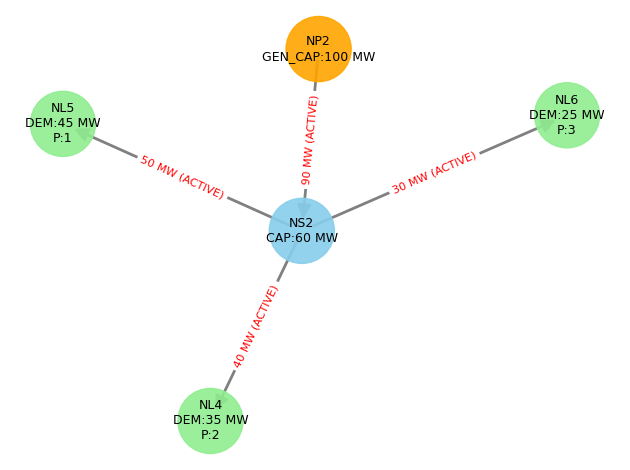

In [22]:
# -----------------------------
# Grid DAG Visualization (GENERATION_CAPACITY_CHANGE)
# -----------------------------
import networkx as nx
import matplotlib.pyplot as plt

def draw_grid_dag_generation_event(dag):
    """
    Draw a DAG of the grid for generation capacity change events.

    Nodes:
      - Plants/Substations: show capacity_mw
      - Loads: show demand_mw and priority
    Edges:
      - show capacity_mw and status (ACTIVE/INACTIVE)

    Highlights the effect of generation capacity changes.
    """
    G = nx.DiGraph()
    
    # Add nodes
    for node_id, node in dag.nodes.items():
        G.add_node(node_id)
    
    # Add edges
    for edge in dag.all_edges():
        G.add_edge(edge.from_node, edge.to_node)
    
    # Node labels and colors
    labels = {}
    colors = []
    for node_id, node in dag.nodes.items():
        if node.type == GridNodeType.PLANT:
            labels[node_id] = f"{node_id}\nGEN_CAP:{node.capacity_mw} MW"
            colors.append('orange')  # highlight plants
        elif node.type == GridNodeType.SUBSTATION:
            labels[node_id] = f"{node_id}\nCAP:{node.capacity_mw} MW"
            colors.append('skyblue')
        elif node.type == GridNodeType.LOAD:
            labels[node_id] = f"{node_id}\nDEM:{node.demand_mw} MW\nP:{node.priority}"
            colors.append('lightgreen')
        else:
            labels[node_id] = node_id
            colors.append('lightgray')
    
    # Use graphviz layout if available, else spring layout
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
    except:
        pos = nx.spring_layout(G, seed=42, k=1.5)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=2200, alpha=0.9)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, edge_color='gray', width=2)
    
    # Draw node labels
    nx.draw_networkx_labels(G, pos, labels, font_size=9)
    
    # Edge labels with capacity and status
    edge_labels = {
        (e.from_node, e.to_node): f"{e.capacity_mw} MW ({e.status.name})"
        for e in dag.all_edges()
    }
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=8)
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Display DAG for generation capacity change event
draw_grid_dag_generation_event(dag2)


In [23]:
# Applying generation capacity change event 

final_grid, event_report = handle_generation_capacity_change_event(dag2, 'NP2', 90)

print("Final Grid", final_grid)
print("Event Report", event_report)

Final Grid DAG(nodes=['NP2', 'NS2', 'NL4', 'NL5', 'NL6'], edges=['E5', 'E6', 'E7', 'E8'], adj={ NP2: ['NS2'], NS2: ['NL4', 'NL5', 'NL6'], NL4: [], NL5: [], NL6: [] })
Event Report {'event': 'GENERATION_CAPACITY_CHANGE', 'plant_id': 'NP2', 'new_capacity_mw': 90, 'initial_violations': [], 'redistribution_violations': ['NL5'], 'load_shedding': [{'load_id': 'NL5', 'priority': 1, 'shed_mw': 45, 'new_demand_mw': 0, 'reason': 'PLANT_CAPACITY_LIMIT_EXCEEDED'}], 'final_unserved_loads': [], 'status': 'STABLE'}


### Visualize Graph AFTER EVENT 
#### Code

/tmp/ipykernel_288366/992470435.py:56: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, edge_color='gray', width=2)


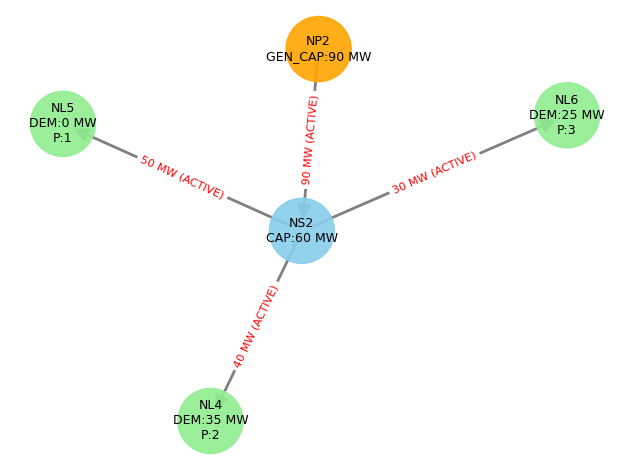

In [24]:
# -----------------------------
# Grid DAG Visualization after event
# -----------------------------

draw_grid_dag_generation_event(dag2)  # DAG object from GridSnapshot after event

## TIME_BASED_DEMAND_SURGE Event (12 PM)

### Mutation Step

#### Purpose

Apply a `TIME_BASED_DEMAND_SURGE` event to the grid at 12 PM.  
This step performs the **direct mutation** of the solar plant's generation output to reflect midday availability, increases load demand according to the surge, validates basic constraints, and identifies the affected portion of the grid (island) for further simulation steps.

---

#### Inputs

- **dag** (`DAG`): The directed acyclic graph representing the current grid state.  
- **solar_plant_id** (`str`): ID of the solar plant node whose output increases at 12 PM.  
- **demand_increase_mw** (`float`): Total additional load demand (MW) to apply to affected load nodes.

---

#### Outputs

- **affected_island** (`set[str]`): Set of node IDs connected to the solar plant and loads, forming the affected island.  
- **violations** (`list[str]`): List of any immediate invariant violations detected during the mutation (e.g., negative capacity or demand).

---

#### Algorithm (Steps)

1. **Retrieve solar node**
    - Find the solar plant object in `dag.nodes` using `solar_plant_id`.
    - Raise error if the node is not found.

2. **Check type**
    - Ensure the node type is `PLANT` and specifically solar.
    - Raise a `TypeError` if the node is not a solar plant.

3. **Apply solar mutation**
    - Update `node.capacity_mw` to reflect midday output (`max_capacity_mw` or event-specified value).

4. **Apply demand surge**
    - Identify all load nodes in the affected island (connected to the solar plant).
    - Increase each load's `capacity_mw` proportionally to represent the total `demand_increase_mw`.

5. **Validate immediate invariants**
    - If any node's `capacity_mw < 0`, append a corresponding violation message and set `capacity_mw = 0`.

6. **Identify affected island**
    - Call `dag.find_island(solar_plant_id)` to determine all nodes connected to the changed solar plant.
    - Return this set as `affected_island`.

---

#### Notes

- **Hydro generation remains unchanged**; only solar output increases.  
- **Redistribution and corrective actions** (e.g., redispatch of flexible plants or load shedding) are **not part of this step**; they are applied afterward to rebalance the grid.  
- This step is **deterministic** and **stateless**, producing the same outputs for the same inputs.  
- `capacity_mw` represents the **effective available power**, consistent with the SGMS modeling convention.

---

#### Example Usage

```python
affected_island, violations = apply_time_based_demand_surge(
    dag,
    solar_plant_id="SP1",
    demand_increase_mw=50
)
print("Affected nodes:", affected_island)
print("Violations:", violations)


In [25]:
# -----------------------------
# Create a GridSnapshot for Time-Based Demand Surge (12 PM)
# -----------------------------

# Nodes
hydro_plant = Node(
    id="NH3",
    type=GridNodeType.PLANT,
    plant_type=PlantType.HYDRO,
    capacity_mw=120,  # hydro remains unchanged
    priority=1
)

solar_plant = Node(
    id="SP3",
    type=GridNodeType.PLANT,
    plant_type=PlantType.SOLAR,
    capacity_mw=0,  # will increase automatically at 12 PM
    priority=1
)

substation = Node(
    id="NS3",
    type=GridNodeType.SUBSTATION,
    capacity_mw=100,
    priority=1
)

load1 = Node(
    id="NL7",
    type=GridNodeType.LOAD,
    load_type=LoadType.HOSPITAL,
    demand_mw=50,
    priority=2
)

load2 = Node(
    id="NL8",
    type=GridNodeType.LOAD,
    load_type=LoadType.INDUSTRIAL,
    demand_mw=70,
    priority=1
)

load3 = Node(
    id="NL9",
    type=GridNodeType.LOAD,
    load_type=LoadType.RESIDENTIAL,
    demand_mw=30,
    priority=3
)

# Edges
e1 = Edge(
    id="E9",
    from_node=hydro_plant,
    to_node=substation,
    capacity_mw=100,
    resistance=0.02,
    losses_percent=1.5,
    priority=1
)

e2 = Edge(
    id="E10",
    from_node=solar_plant,
    to_node=substation,
    capacity_mw=50,  # max transfer from solar
    resistance=0.01,
    losses_percent=0.5,
    priority=1
)

e3 = Edge(
    id="E11",
    from_node=substation,
    to_node=load1,
    capacity_mw=60,
    resistance=0.01,
    losses_percent=0.5,
    priority=1
)

e4 = Edge(
    id="E12",
    from_node=substation,
    to_node=load2,
    capacity_mw=80,
    resistance=0.015,
    losses_percent=0.8,
    priority=1
)

e5 = Edge(
    id="E13",
    from_node=substation,
    to_node=load3,
    capacity_mw=50,
    resistance=0.02,
    losses_percent=1.0,
    priority=2
)

# Grid metadata
metadata = {
    "base_power_mva": 100.0,
    "voltage_level": "110kV",
    "description": "Sample simulation grid with solar plant for 12 PM surge"
}

# Create GridSnapshot
grid_snapshot = GridSnapshot(
    nodes=[hydro_plant, solar_plant, substation, load1, load2, load3],
    edges=[e1, e2, e3, e4, e5],
    metadata=metadata
)

# Display Grid Snapshot
print(grid_snapshot)

# Implement the DAG for the snapshot
dag3 = grid_snapshot.to_dag()
print(dag3)


GridSnapshot(nodes=['NH3', 'SP3', 'NS3', 'NL7', 'NL8', 'NL9'], edges=['E9', 'E10', 'E11', 'E12', 'E13'], metadata={'base_power_mva': 100.0, 'voltage_level': '110kV', 'description': 'Sample simulation grid with solar plant for 12 PM surge'})
DAG(nodes=['NH3', 'SP3', 'NS3', 'NL7', 'NL8', 'NL9'], edges=['E9', 'E10', 'E11', 'E12', 'E13'], adj={ NH3: ['NS3'], SP3: ['NS3'], NS3: ['NL7', 'NL8', 'NL9'], NL7: [], NL8: [], NL9: [] })


In [26]:
# -----------------------------
# Mutation Algorithm for Time-Based Generation Surge (12 PM)
# -----------------------------
def apply_time_based_generation_surge(
    dag: DAG,
    solar_plant_id: str,
    new_capacity_mw: float
):
    """
    Apply a TIME_BASED_GENERATION_SURGE event (12 PM).

    This models increased solar output at midday by explicitly
    mutating the capacity of an existing solar plant.

    Returns:
        affected_island (set): IDs of all nodes connected to the solar plant
        violations (list): any detected immediate violations
    """
    violations = []

    # Step 0: Retrieve solar plant
    plant = dag.nodes.get(solar_plant_id)
    if plant is None:
        raise ValueError(f"Node {solar_plant_id} not found in DAG")

    # Step 1: Validate plant type
    if plant.type != GridNodeType.PLANT or plant.plant_type != PlantType.SOLAR:
        raise TypeError(
            f"Node {solar_plant_id} is not a SOLAR PLANT "
            f"(type={plant.type}, plant_type={getattr(plant, 'plant_type', None)})"
        )

    # Step 2: Apply explicit capacity mutation (midday surge)
    plant.capacity_mw = new_capacity_mw

    # Step 3: Validate invariants
    if plant.capacity_mw < 0:
        violations.append("INVALID_CAPACITY: capacity < 0")
        plant.capacity_mw = 0

    # Step 4: Identify affected island
    affected_island = dag.find_island(solar_plant_id)

    return affected_island, violations


In [27]:
# -----------------------------
# Applying the Time-Based Demand Surge at 12 PM
# -----------------------------

# Increase solar output (e.g., 50 MW total surge)
affected_island, violations = apply_time_based_generation_surge(
    dag3,
    solar_plant_id='SP3',
    new_capacity_mw=50
)

print("Affected Island:", affected_island, "\n", "Violations:", violations)


Affected Island: {'NL9', 'NL7', 'NS3', 'SP3', 'NL8', 'NH3'} 
 Violations: []


### Redistribution Process (After TIME_BASED_DEMAND_SURGE – 12 PM)

Redistribution allocates available power from plants to loads based on priority and constrained by edge and substation capacities.  
When a **time-based demand surge occurs at 12 PM**, the grid must **rebalance power flow** to accommodate increased load demand and updated solar generation output while respecting physical limits.

---

#### `redistribute_power(dag, affected_island)`

**Purpose:**  
Main function to perform priority-based redistribution of power within the affected island after a **time-based demand surge mutation**.

This redistribution is triggered after:
- Solar plant output increases (midday availability)
- Load demand increases due to peak-time consumption

**Inputs:**  
- `dag`: The directed acyclic graph representing the grid.  
- `affected_island`: Set of node IDs impacted by the time-based event (from `apply_time_based_demand_surge`).

**Outputs:**  
- `plant_remaining`: Remaining generation capacity at each plant (solar + other plants).  
- `load_remaining`: Remaining unmet demand at each load after redistribution.  
- `violations`: Loads that could not be fully supplied under current constraints.

**Notes:**  
- Iterates over loads sorted by priority (e.g., hospitals first).  
- Calls `find_supply_paths` to locate upstream supply paths for each load.  
- Applies power along each path constrained by plant, substation, and edge capacities.  
- Updates runtime state for edges, plants, and substations.  

---

#### `find_supply_paths(dag, load_id)`

**Purpose:**  
Identify all active upstream paths from a load to plants in the DAG during a time-based surge.

**Inputs:**  
- `dag`: The grid DAG.  
- `load_id`: The target load node ID.

**Outputs:**  
- List of tuples `(path_nodes, path_edges)` representing sequences of node IDs and edge IDs along the supply path.

**Notes:**  
- Uses depth-first search (DFS) on `rev_adj` to traverse upstream.  
- Stops at plant nodes (including solar and non-solar plants).  
- Only includes edges that are `ACTIVE`.  
- Provides all candidate paths for redistribution, enabling priority-based allocation under peak demand conditions.  

---

#### Runtime State Tracking

Redistribution uses temporary dictionaries to track remaining capacities during computation:

- **`plant_remaining`**: Tracks how much power each plant can still provide after the midday solar increase.  
- **`substation_remaining`**: Tracks remaining throughput at substations.  
- **`edge_remaining`**: Tracks remaining capacity along edges.  
- **`load_remaining`**: Tracks unmet demand after the time-based demand surge.

**Why:**  
Ensures no capacity limits are violated and supports stepwise allocation without modifying DAG structure.

---

#### Redistribution Logic (Time-Based Demand Surge)

For each load (highest priority first):

1. **Locate upstream paths** using `find_supply_paths`.  
2. **Compute transferable power** along each path considering:  
   - Remaining plant capacity (`plant_remaining`)  
   - Remaining substation throughput (`substation_remaining`)  
   - Remaining edge capacities (`edge_remaining`)  
   - Increased load demand (`load_remaining`)  

3. **Update runtime state** to reflect the applied power.  
4. **Record violations** if a load could not be fully supplied after the surge.

---

#### Key Insight

Redistribution logic is **identical** to other events.  
Only the **cause of imbalance** differs:

- `PLANT_CAPACITY_CHANGE` → generation-side shock  
- `TIME_BASED_DEMAND_SURGE (12 PM)` → demand-side shock + renewable boost  

The grid responds the same way: **rebalance → constrain → correct if needed**.


In [28]:
# -----------------------------
# Runtime State Initialization (Time-Based Demand Surge)
# -----------------------------
def initialize_runtime_state_for_time_surge(dag: DAG, affected_island: set):
    """
    Initialize temporary state for redistribution after a TIME_BASED_DEMAND_SURGE event:
    - plant_remaining: available generation (includes solar midday boost)
    - substation_remaining: remaining throughput at substations
    - edge_remaining: remaining capacity of edges
    - load_remaining: remaining demand (includes 12 PM demand surge)
    """
    plant_remaining = {}
    substation_remaining = {}
    edge_remaining = {}
    load_remaining = {}
    
    for node_id in affected_island:
        node = dag.nodes[node_id]
        if node.type == GridNodeType.PLANT:
            plant_remaining[node_id] = node.capacity_mw
        elif node.type == GridNodeType.SUBSTATION:
            substation_remaining[node_id] = node.capacity_mw
        elif node.type == GridNodeType.LOAD:
            load_remaining[node_id] = node.demand_mw

    for edge in dag.all_edges():
        if edge.from_node in affected_island and edge.to_node in affected_island:
            edge_remaining[edge.id] = edge.capacity_mw

    return plant_remaining, substation_remaining, edge_remaining, load_remaining


In [29]:
# -----------------------------
# Find Supply Paths
# -----------------------------
def find_supply_paths(dag: DAG, load_id: str):
    """
    Find all active upstream paths from a load to plants.
    Used during time-based demand surge redistribution.
    """
    paths = []
    
    def dfs(current_node, path_nodes, path_edges):
        node_obj = dag.nodes[current_node]
        if node_obj.type == GridNodeType.PLANT:
            paths.append((path_nodes + [current_node], path_edges))
            return
        for edge in dag.incoming_edges(current_node):
            if edge.status == GridEdgeStatus.ACTIVE:
                dfs(edge.from_node, path_nodes + [current_node], path_edges + [edge.id])
    
    dfs(load_id, [], [])
    return paths


In [30]:
# -----------------------------
# Apply Power Along Path (Time-Based Event)
# -----------------------------
def apply_power_along_path_for_time_surge(
    path_nodes,
    path_edges,
    plant_remaining,
    substation_remaining,
    edge_remaining,
    load_remaining
):
    """
    Allocate power along a path during a time-based demand surge.
    Updates runtime state dictionaries in-place.
    """
    plant_node = path_nodes[-1]
    load_node = path_nodes[0]
    
    min_edge_capacity = min(edge_remaining[eid] for eid in path_edges) if path_edges else float('inf')
    min_substation_capacity = min(substation_remaining.get(nid, float('inf')) for nid in path_nodes)
    
    transferable = min(
        plant_remaining[plant_node],
        load_remaining[load_node],
        min_edge_capacity,
        min_substation_capacity
    )
    
    plant_remaining[plant_node] -= transferable
    load_remaining[load_node] -= transferable
    
    for edge_id in path_edges:
        edge_remaining[edge_id] -= transferable
    for nid in path_nodes:
        if nid in substation_remaining:
            substation_remaining[nid] -= transferable
            
    return transferable


In [31]:
# -----------------------------
# Redistribution Main Function (Time-Based Demand Surge)
# -----------------------------
def redistribute_power_after_time_surge(dag: DAG, affected_island: set):
    """
    Priority-based redistribution after a TIME_BASED_DEMAND_SURGE (12 PM).
    Loads are served based on priority under updated generation and demand.
    
    Returns:
        plant_remaining
        load_remaining
        violations (loads that could not be fully supplied)
    """
    (
        plant_remaining,
        substation_remaining,
        edge_remaining,
        load_remaining
    ) = initialize_runtime_state_for_time_surge(dag, affected_island)

    violations = []

    # Sort loads by priority (higher first)
    loads = [
        dag.nodes[nid]
        for nid in affected_island
        if dag.nodes[nid].type == GridNodeType.LOAD
    ]
    loads.sort(key=lambda x: -x.priority)

    for load in loads:
        while load_remaining[load.id] > 0:
            paths = find_supply_paths(dag, load.id)
            if not paths:
                break

            transferred = 0
            for nodes_path, edges_path in paths:
                power = apply_power_along_path_for_time_surge(
                    nodes_path,
                    edges_path,
                    plant_remaining,
                    substation_remaining,
                    edge_remaining,
                    load_remaining
                )
                transferred += power
                if load_remaining[load.id] <= 0:
                    break

            if transferred == 0:
                # Peak demand cannot be satisfied → corrective action needed
                violations.append(load.id)
                break

    return plant_remaining, load_remaining, violations


### Load Shedding Algorithm (Time-Based Demand Surge – 12 PM)

#### Purpose

The **Load Shedding Algorithm** is a corrective mechanism executed **after power redistribution** when the grid cannot satisfy all load demands during a **time-based demand surge (12 PM)**.

Load shedding **intentionally reduces or removes load demand** to restore grid feasibility while respecting **load priority rules** under peak-time conditions.

---

#### When Load Shedding Is Triggered

Load shedding is applied **only if**:

- The **time-based demand surge mutation** has been applied (solar output increased, load demand increased), and  
- Power redistribution completes, and  
- One or more loads still have **unmet demand**

Formally:

```text
∃ load ∈ affected_island such that load_remaining[load] > 0


In [32]:
# -----------------------------
# Load Shedding Algorithm
# (Time-Based Demand Surge – 12 PM)
# -----------------------------
def apply_load_shedding_after_time_surge(
    dag: DAG,
    affected_island: set,
    load_remaining: dict,
):
    """
    Reduce load demands to restore feasibility after a TIME_BASED_DEMAND_SURGE (12 PM).

    Shedding is applied only to loads whose demand could not be
    satisfied due to peak-time demand exceeding available generation
    and network constraints, even after solar generation increase.

    Returns:
        shedding_report (list of dicts)
    """
    shedding_report = []

    # Step 1: Identify unsatisfied loads (after redistribution)
    unsatisfied_loads = [
        dag.nodes[lid]
        for lid, remaining in load_remaining.items()
        if remaining > 0 and lid in affected_island
    ]

    # Step 2: Sort loads by priority (LOW priority shed first)
    unsatisfied_loads.sort(key=lambda x: x.priority)

    # Step 3: Apply shedding to reduce unmet demand
    for load in unsatisfied_loads:
        remaining_unmet = load_remaining.get(load.id, 0)
        if remaining_unmet <= 0:
            continue

        original_demand = load.demand_mw

        # Shed only what is necessary (partial or full)
        shed_amount = min(original_demand, remaining_unmet)

        # Apply shedding (persistent mutation)
        load.demand_mw -= shed_amount
        load_remaining[load.id] -= shed_amount

        shedding_report.append({
            "load_id": load.id,
            "priority": load.priority,
            "shed_mw": shed_amount,
            "new_demand_mw": load.demand_mw,
            "reason": "TIME_BASED_PEAK_DEMAND_EXCEEDED",
        })

        # Stop early if all unmet demand has been eliminated
        if all(v <= 0 for v in load_remaining.values()):
            break

    return shedding_report


## Time-Based GENERATION_CAPACITY_CHANGE Event Handling Algorithm

### Purpose

This algorithm defines the **time-aware lifecycle** of a `GENERATION_CAPACITY_CHANGE` event in the smart grid simulation.

A generation capacity change:
- Occurs at a **specific simulation time**
- May represent **planned maintenance**, **renewable fluctuation**, or **unit failure**
- Triggers **delayed grid reactions**, not instantaneous stabilization

The grid must **react over time**, redistribute power, and apply **corrective actions** (e.g. load shedding) until stability is restored or the grid becomes infeasible.

---

### Event Definition

```text
Event Type: GENERATION_CAPACITY_CHANGE
Attributes:
- target_node_id
- capacity_delta_mw (positive or negative)
- event_time
```

---

#### High-Level Flow

```text
TIME t = event_time
   ↓
Apply State Mutation (update generation capacity)
   ↓
Schedule Power Redistribution (t + Δredispatch)
   ↓
Run Power Redistribution
   ↓
Is Grid Stable at time t + Δredispatch?
   ├── Yes → Record Stable State → End
   └── No
        ↓
Schedule Corrective Measures (t + Δcorrective)
        ↓
Apply Load Shedding (priority-based)
        ↓
Schedule Power Redistribution (t + Δredispatch)
        ↓
Re-evaluate Grid Stability
        ↓
Final Stable State OR Infeasible Grid


In [33]:
# -----------------------------
# Time-Based GENERATION_SURGE Event Handler
# (Phase-based, no scheduler, in-place DAG mutation)
# -----------------------------
def handle_time_based_generation_surge_event(
    dag: DAG,
    plant_id: str,
    new_capacity_mw: float
):
    """
    Time-based GENERATION_SURGE event handler.

    Semantic meaning:
    - A temporary or sudden surge in generation capacity
    - Time is modeled via discrete system response phases (no scheduler)

    Phases:
      t0: Surge application on plant (capacity mutation)
      t1: Power redistribution within affected island
      t2: Corrective actions if violations appear
      t3: Final stabilization redistribution

    All mutations are applied in-place to the DAG.
    """

    event_report = {
        "event": "TIME_BASED_GENERATION_SURGE",
        "plant_id": plant_id,
        "new_capacity_mw": new_capacity_mw,
        "timeline": [],
        "status": "STABLE",
        "final_unserved_loads": []
    }

    # -----------------------------
    # t0 — Surge Application (Capacity Mutation)
    # -----------------------------
    affected_island, violations = apply_time_based_generation_surge(
        dag=dag,
        plant_id=plant_id,
        new_capacity_mw=new_capacity_mw
    )

    event_report["timeline"].append({
        "phase": "t0",
        "action": "GENERATION_SURGE_APPLIED",
        "violations": violations
    })

    # -----------------------------
    # t1 — Power Redistribution
    # -----------------------------
    plant_remaining, load_remaining, redistribution_violations = (
        redistribute_power_after_plant_change(
            dag=dag,
            affected_island=affected_island
        )
    )

    event_report["timeline"].append({
        "phase": "t1",
        "action": "POWER_REDISTRIBUTION",
        "violations": redistribution_violations
    })

    # -----------------------------
    # t2 — Corrective Measures (only if needed)
    # -----------------------------
    if redistribution_violations:
        shedding_report = apply_load_shedding_after_plant_change(
            dag=dag,
            affected_island=affected_island,
            load_remaining=load_remaining
        )

        event_report["timeline"].append({
            "phase": "t2",
            "action": "CORRECTIVE_LOAD_SHEDDING",
            "details": shedding_report
        })

        # -----------------------------
        # t3 — Final Stabilization Redistribution
        # -----------------------------
        _, final_load_remaining, final_violations = (
            redistribute_power_after_plant_change(
                dag=dag,
                affected_island=affected_island
            )
        )

        event_report["timeline"].append({
            "phase": "t3",
            "action": "FINAL_STABILIZATION",
            "violations": final_violations
        })

        if final_violations:
            event_report["status"] = "INFEASIBLE"
            event_report["final_unserved_loads"] = final_violations
        else:
            event_report["status"] = "STABLE"

    return dag, event_report


### TESTING
#### Code

In [34]:
# -----------------------------
# Create a GridSnapshot for Time-Based Generation Surge (12 PM) – Example 4
# -----------------------------

# Nodes
hydro_plant_4 = Node(
    id="NH4",
    type=GridNodeType.PLANT,
    plant_type=PlantType.HYDRO,
    capacity_mw=90,   # fixed hydro generation
    priority=1
)

solar_plant_4 = Node(
    id="SP4",
    type=GridNodeType.PLANT,
    plant_type=PlantType.SOLAR,
    capacity_mw=20,   # early morning output (pre-12PM)
    priority=1
)

substation_4 = Node(
    id="NS4",
    type=GridNodeType.SUBSTATION,
    capacity_mw=85,   # constrained substation
    priority=1
)

load10 = Node(
    id="NL10",
    type=GridNodeType.LOAD,
    load_type=LoadType.HOSPITAL,
    demand_mw=40,
    priority=3
)

load11 = Node(
    id="NL11",
    type=GridNodeType.LOAD,
    load_type=LoadType.INDUSTRIAL,
    demand_mw=55,
    priority=2
)

load12 = Node(
    id="NL12",
    type=GridNodeType.LOAD,
    load_type=LoadType.RESIDENTIAL,
    demand_mw=35,
    priority=1
)

# Edges
e14 = Edge(
    id="E14",
    from_node=hydro_plant_4,
    to_node=substation_4,
    capacity_mw=70,   # bottleneck on hydro line
    resistance=0.018,
    losses_percent=1.3,
    priority=1
)

e15 = Edge(
    id="E15",
    from_node=solar_plant_4,
    to_node=substation_4,
    capacity_mw=45,   # solar export limit
    resistance=0.010,
    losses_percent=0.6,
    priority=1
)

e16 = Edge(
    id="E16",
    from_node=substation_4,
    to_node=load10,
    capacity_mw=45,
    resistance=0.008,
    losses_percent=0.4,
    priority=1
)

e17 = Edge(
    id="E17",
    from_node=substation_4,
    to_node=load11,
    capacity_mw=50,
    resistance=0.012,
    losses_percent=0.7,
    priority=1
)

e18 = Edge(
    id="E18",
    from_node=substation_4,
    to_node=load12,
    capacity_mw=30,
    resistance=0.015,
    losses_percent=0.9,
    priority=2
)

# Grid metadata
metadata4 = {
    "base_power_mva": 85.0,
    "voltage_level": "33kV",
    "description": "Time-based solar generation surge test with constrained substation"
}

# Create GridSnapshot
grid_snapshot4 = GridSnapshot(
    nodes=[
        hydro_plant_4,
        solar_plant_4,
        substation_4,
        load10,
        load11,
        load12
    ],
    edges=[e14, e15, e16, e17, e18],
    metadata=metadata4
)

# Display snapshot
print(grid_snapshot4)

# Convert snapshot to DAG
dag4 = grid_snapshot4.to_dag()
print(dag4)


GridSnapshot(nodes=['NH4', 'SP4', 'NS4', 'NL10', 'NL11', 'NL12'], edges=['E14', 'E15', 'E16', 'E17', 'E18'], metadata={'base_power_mva': 85.0, 'voltage_level': '33kV', 'description': 'Time-based solar generation surge test with constrained substation'})
DAG(nodes=['NH4', 'SP4', 'NS4', 'NL10', 'NL11', 'NL12'], edges=['E14', 'E15', 'E16', 'E17', 'E18'], adj={ NH4: ['NS4'], SP4: ['NS4'], NS4: ['NL10', 'NL11', 'NL12'], NL10: [], NL11: [], NL12: [] })


### Visualize Graph BEFORE EVENT 
#### Code

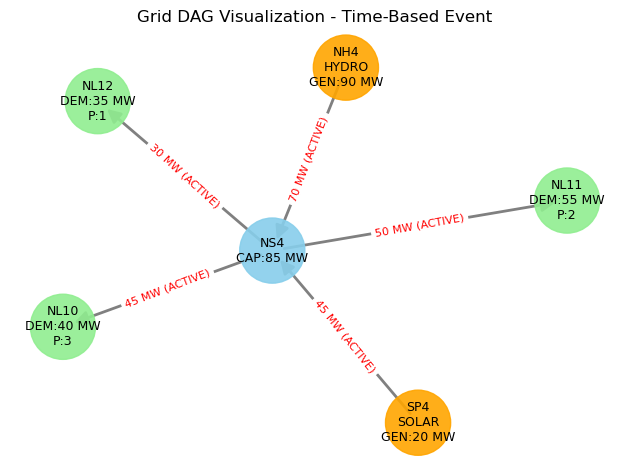

In [35]:
# -----------------------------
# Grid DAG Visualization (Time-Based Event, Simplified)
# -----------------------------
import networkx as nx
import matplotlib.pyplot as plt

def draw_grid_dag_time_event(dag):
    """
    Draw a DAG of the grid for time-based generation events.

    Highlights:
      - Plants: show capacity_mw and plant_type
      - Substations: show capacity_mw
      - Loads: show demand_mw and priority
      - Edges: show capacity and status
    """
    G = nx.DiGraph()
    
    # Add nodes
    for node_id, node in dag.nodes.items():
        G.add_node(node_id)
    
    # Add edges
    for edge in dag.all_edges():
        G.add_edge(edge.from_node, edge.to_node)
    
    # Node labels and colors
    labels = {}
    colors = []
    for node_id, node in dag.nodes.items():
        if node.type == GridNodeType.PLANT:
            labels[node_id] = f"{node_id}\n{node.plant_type.name}\nGEN:{node.capacity_mw} MW"
            colors.append('orange')  # Plants in orange
        elif node.type == GridNodeType.SUBSTATION:
            labels[node_id] = f"{node_id}\nCAP:{node.capacity_mw} MW"
            colors.append('skyblue')
        elif node.type == GridNodeType.LOAD:
            labels[node_id] = f"{node_id}\nDEM:{node.demand_mw} MW\nP:{node.priority}"
            colors.append('lightgreen')
        else:
            labels[node_id] = node_id
            colors.append('lightgray')
    
    # Layout
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
    except:
        pos = nx.spring_layout(G, seed=42, k=1.5)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=2200, alpha=0.9)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, edge_color='gray', width=2)
    
    # Draw node labels
    nx.draw_networkx_labels(G, pos, labels, font_size=9)
    
    # Edge labels with capacity and status
    edge_labels = {
        (e.from_node, e.to_node): f"{e.capacity_mw} MW ({e.status.name})"
        for e in dag.all_edges()
    }
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=8)
    
    plt.title("Grid DAG Visualization - Time-Based Event", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


# -----------------------------
# Example usage for NP3 time-based surge
# -----------------------------
draw_grid_dag_time_event(dag4)


In [36]:
# -----------------------------
# Apply Time-Based Generation Surge (12 PM)
# -----------------------------

# At 12 PM, solar output increases from 20 MW → 60 MW
final_grid_4, event_report_4 = handle_generation_capacity_change_event(
    dag4,
    plant_id="SP4",
    new_capacity_mw=60
)

print("Final Grid:", final_grid_4)
print("\nEvent Report:", event_report_4)


Final Grid: DAG(nodes=['NH4', 'SP4', 'NS4', 'NL10', 'NL11', 'NL12'], edges=['E14', 'E15', 'E16', 'E17', 'E18'], adj={ NH4: ['NS4'], SP4: ['NS4'], NS4: ['NL10', 'NL11', 'NL12'], NL10: [], NL11: [], NL12: [] })

Event Report: {'event': 'GENERATION_CAPACITY_CHANGE', 'plant_id': 'SP4', 'new_capacity_mw': 60, 'initial_violations': [], 'redistribution_violations': ['NL11', 'NL12'], 'load_shedding': [{'load_id': 'NL12', 'priority': 1, 'shed_mw': 35, 'new_demand_mw': 0, 'reason': 'PLANT_CAPACITY_LIMIT_EXCEEDED'}, {'load_id': 'NL11', 'priority': 2, 'shed_mw': 10, 'new_demand_mw': 45, 'reason': 'PLANT_CAPACITY_LIMIT_EXCEEDED'}], 'final_unserved_loads': [], 'status': 'STABLE'}


### Visualize Graph AFTER EVENT 
#### Code

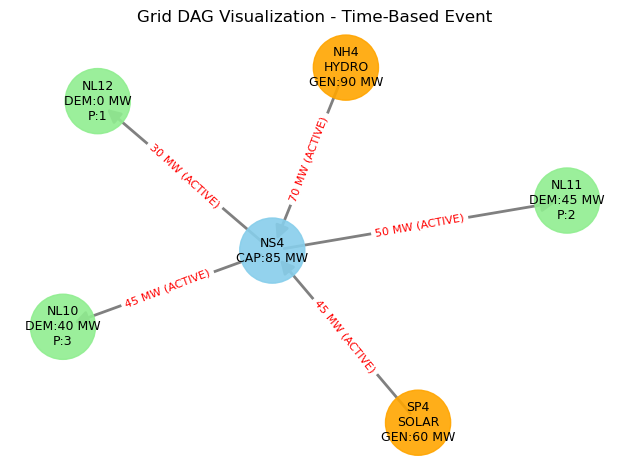

In [37]:
# Visualize the updated grid

draw_grid_dag_time_event(final_grid_4)
